In [1]:
# train a Neural Network (MLPClassifier) to predict thyroid tumor malignancy
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.base import clone
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

In [2]:
def load_data(data_dir: Path):
    X_train = pd.read_csv(data_dir / "X_train.csv")
    y_train = pd.read_csv(data_dir / "y_train.csv")
    X_test = pd.read_csv(data_dir / "X_test.csv")
    y_test = pd.read_csv(data_dir / "y_test.csv")

    # Flatten y if it is a column vector
    y_train = y_train.values.ravel()
    y_test = y_test.values.ravel()

    # Encode string labels to integers
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    return X_train, y_train, X_test, y_test

In [3]:
def build_pipeline(X: pd.DataFrame):
    # Determine numeric vs categorical columns
    numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    print(f"Numeric cols ({len(numeric_cols)}): {numeric_cols}")
    print(f"Categorical cols ({len(categorical_cols)}): {categorical_cols}")

    numeric_transformer = Pipeline([
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ], remainder="drop")

    clf = MLPClassifier(random_state=42, max_iter=500)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", clf)
    ])

    return pipe

In [4]:
def main():
    data_dir = Path("data")
    X_train, y_train, X_test, y_test = load_data(data_dir)

    pipe = build_pipeline(X_train)

    # StratifiedKFold for stable splits
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Hyperparameter grid for Neural Network
    param_grid = {
        "clf__hidden_layer_sizes": [(50,), (100,), (100, 50)],
        "clf__activation": ["relu", "tanh"],
        "clf__alpha": [0.0001, 0.001],  # L2 regularization
        "clf__learning_rate_init": [0.001, 0.01]
    }

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        n_jobs=-1,
        cv=cv,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)

    print("\nBest performing Neural Network model:")
    print(grid.best_estimator_)
    print("\nBest hyperparameters:")
    print(grid.best_params_)
    print(f"Best CV AUC: {grid.best_score_:.4f}")

    print(f"Training set y shape: {y_train.shape}")
    print(f"Test set y shape: {y_test.shape}")
    print(f"Training set X shape: {X_train.shape}")
    print(f"Test set X shape: {X_test.shape}")

    # Define metrics for cross-validation
    scoring = {
        "accuracy": make_scorer(accuracy_score),
        "precision": make_scorer(precision_score, pos_label=1),
        "recall": make_scorer(recall_score, pos_label=1),
        "f1": make_scorer(f1_score, pos_label=1),
        "auc": "roc_auc"
    }

    # Evaluate all hyperparameter combinations
    results = []
    for params in grid.cv_results_["params"]:
        model = clone(pipe)
        model.set_params(**params)
        scores = cross_validate(
            model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
        )
        results.append({
            **params,
            "accuracy": scores["test_accuracy"].mean(),
            "precision": scores["test_precision"].mean(),
            "recall": scores["test_recall"].mean(),
            "f1": scores["test_f1"].mean(),
            "auc": scores["test_auc"].mean()
        })

    metrics_df = pd.DataFrame(results)
    print("\nMetrics for all Neural Network models (averaged across folds):")
    print(metrics_df.sort_values("auc", ascending=False))

    Path("results").mkdir(exist_ok=True)
    metrics_df.to_csv("results/nn_model_metrics.csv", index=False)
    print("Saved metrics table to results/nn_model_metrics.csv")

    # Evaluate best model
    best_model = grid.best_estimator_

    scores_best = cross_validate(best_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print("\nError metrics for the best model on training data (averaged across folds):")
    print(f"Accuracy:              {scores_best['test_accuracy'].mean():.4f}")
    print(f"Precision (Malignant): {scores_best['test_precision'].mean():.4f}")
    print(f"Recall (Malignant):    {scores_best['test_recall'].mean():.4f}")
    print(f"F1 (Malignant):        {scores_best['test_f1'].mean():.4f}")
    print(f"AUC:                   {scores_best['test_auc'].mean():.4f}")

    # ROC curve on training data
    y_prob_train = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_train, y_prob_train, pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Train ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate', fontweight='bold')
    plt.ylabel('True Positive Rate', fontweight='bold')
    plt.title('ROC Curve for Best Neural Network Model on Training Data', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.savefig("results/best_nn_train_roc_curve.png", dpi=300)
    plt.show()

    # Evaluate on test set
    y_pred_test = best_model.predict(X_test)
    y_prob_test = best_model.predict_proba(X_test)[:, 1]
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, pos_label=1)
    recall_test = recall_score(y_test, y_pred_test, pos_label=1)
    f1_test = f1_score(y_test, y_pred_test, pos_label=1)
    auc_test = roc_auc_score(y_test, y_prob_test)

    print("\nError Metrics for Best Neural Network Model on Test Set:")
    print(f"Accuracy:  {accuracy_test:.4f}")
    print(f"Precision: {precision_test:.4f}")
    print(f"Recall:    {recall_test:.4f}")
    print(f"F1:        {f1_test:.4f}")
    print(f"AUC:       {auc_test:.4f}")

    # ROC curve on test data
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_test, pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Test ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate', fontweight='bold')
    plt.ylabel('True Positive Rate', fontweight='bold')
    plt.title('ROC Curve for Best Neural Network Model on Test Data', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.savefig("results/best_nn_test_roc_curve.png", dpi=300)
    plt.show()


Numeric cols (8): ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size', 'Risk_Factor_Score', 'TSH_Nodule_Interact', 'T3_TSH_Ratio']
Categorical cols (9): ['Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes']
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/skle


Best performing Neural Network model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'TSH_Level',
                                                   'T3_Level', 'T4_Level',
                                                   'Nodule_Size',
                                                   'Risk_Factor_Score',
                                                   'TSH_Nodule_Interact',
                                                   'T3_TSH_Ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                       

/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/skle


Metrics for all Neural Network models (averaged across folds):
   clf__activation  clf__alpha clf__hidden_layer_sizes  \
17            tanh      0.0001               (100, 50)   
18            tanh      0.0010                   (50,)   
12            tanh      0.0001                   (50,)   
19            tanh      0.0010                   (50,)   
9             relu      0.0010                  (100,)   
5             relu      0.0001               (100, 50)   
23            tanh      0.0010               (100, 50)   
11            relu      0.0010               (100, 50)   
20            tanh      0.0010                  (100,)   
8             relu      0.0010                  (100,)   
2             relu      0.0001                  (100,)   
21            tanh      0.0010                  (100,)   
15            tanh      0.0001                  (100,)   
6             relu      0.0010                   (50,)   
13            tanh      0.0001                   (50,)   
0       

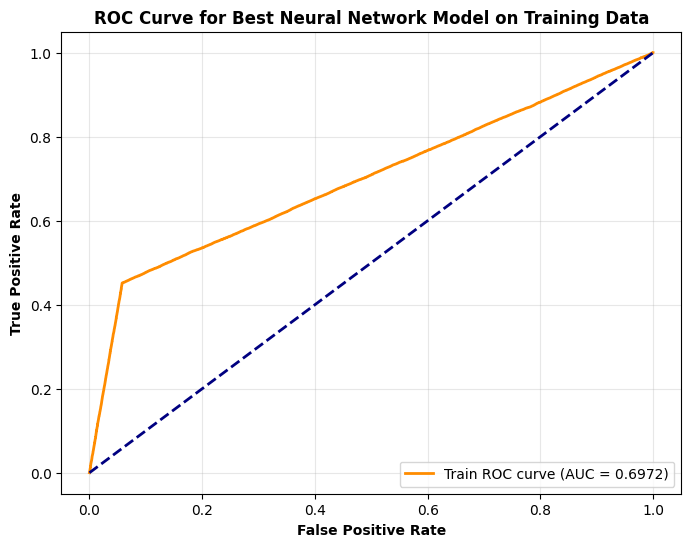


Error Metrics for Best Neural Network Model on Test Set:
Accuracy:  0.8259
Precision: 0.6952
Recall:    0.4478
F1:        0.5447
AUC:       0.6971


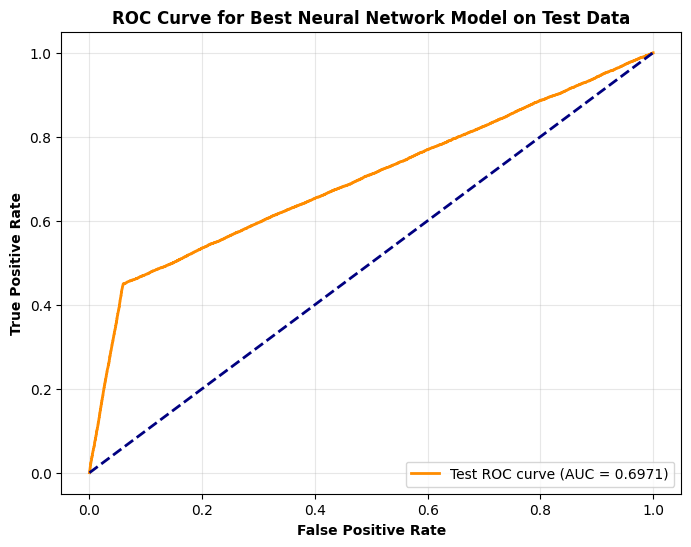

In [5]:
if __name__ == "__main__":
    main()